<a href="https://colab.research.google.com/github/MM33NA/AI-machine-learning-projects/blob/main/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Description**

Project statement:

AAL, established in 2000, is a well-known brand in Australia, particularly recognized for its clothing business. It has opened branches in various states, metropolises, and tier-1 and tier-2 cities across the country.

The brand caters to all age groups, from kids to the elderly.

Currently experiencing a surge in business, AAL is actively pursuing expansion opportunities. To facilitate informed investment decisions, the CEO has assigned the responsibility to the head of AAL’s sales and marketing (S&M) department. The specific tasks include:

- Identify the states that are generating the highest revenues.
- Develop sales programs for states with lower revenues.

The head of sales and marketing has requested your assistance with this task.
- Analyze the sales data of the company for the fourth quarter in Australia, examining it on a state-by-state basis.
- Provide insights to assist the company in making data-driven decisions for the upcoming year.

_Enclosed is the CSV (AusApparalSales4thQrt2020.csv) file that covers the said data._

#### **Import the required libraries and packages**

In [3]:
# import the required libraries
import pandas as pd # Loads the Pandas library, which is a powerful tool for data analysis and manipulation.

# load the library packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#### **Load the dataset**

In [4]:
## The data is saved in GitHub so below is the function to connect the data from Github to Google Colab
import os

# 1. Define the repository URL
repo_url = "https://github.com/MM33NA/AI-machine-learning-projects.git"
repo_name = "AI-machine-learning-projects"

# 2. Clone the repo
if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print("Repository already exists. Pulling latest changes...")
    %cd {repo_name}
    !git pull
    %cd ..

# 3. Move into specific sub-folder to access CSVs directly by name
os.chdir(f"{repo_name}/exploratory-data-analysis")

# 4. Verify the files are there
print("\n Files are ready:")
!ls

Cloning into 'AI-machine-learning-projects'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 15 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 310.29 KiB | 11.93 MiB/s, done.
Resolving deltas: 100% (1/1), done.

 Files are ready:
AusApparalSales4thQrt2020.csv  README.md  sales_analysis.ipynb


In [5]:
# Load the dataset
df = pd.read_csv('AusApparalSales4thQrt2020.csv')

#### **1. Data Wrangling**


a. Ensure that the data is clean and free from any missing or incorrect entries.
- Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().
- Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).
- Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)
- Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.

In [6]:
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [7]:
# to check the null or not null values
#df.isna().sum()
#df.notna().sum()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [9]:
# to see the variables that are categorical
df.select_dtypes(include='object').columns

Index(['Date', 'Time', 'State', 'Group'], dtype='object')

In [10]:
# check the unique categories for the variable Time
df['Time'].unique()

array([' Morning', ' Afternoon', ' Evening'], dtype=object)

In [11]:
# check the unique categories for the variable State
df['State'].unique()

array([' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS'], dtype=object)

In [12]:
# check the unique categories for the variable Group
df['Group'].unique()

array([' Kids', ' Men', ' Women', ' Seniors'], dtype=object)

**Data description:**
- The sample size for this study is 7560.
- There are six variables in the data.
- Four of them are categorical variables:
  - Date
  - Time (' Morning', ' Afternoon', ' Evening')
  - State (' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS')
  - Group (' Kids', ' Men', ' Women', ' Seniors'

- While 2 of them are integer class
  - Unit
  - Sales
- There are no null/missing values in the data.


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit,7560.0,18.005423,12.901403,2.0,8.0,14.0,26.0,65.0
Sales,7560.0,45013.558201,32253.506944,5000.0,20000.0,35000.0,65000.0,162500.0


The descriptive statistics show that the dataset contains 7,560 observations. The average number of units sold is about 18, while the average sales value is approximately 45,013 dollar. Most transactions involve between 8 and 26 units and generate sales between 20,000 dollar and 65,000 dollar.

**Observation:**
- Dataset has no missing values.  
- Data normalization is not required because this step involves exploratory data analysis and descriptive statistics, where maintaining the original scale of the data improves interpretability. Normalization is mainly needed for machine learning algorithms that are sensitive to differences in variable scales.
- All the data types are correct

<span style="color:#FF0000">**Interpretation:**</span>
Since there are no null or missing values and the data types are correct, no further data wrangling is required.



Things I want to explore:

- In which date was the highest sale?
- Which day most of the sales happens?
- Which states has the highest or lowest sales?
- Which Group is doing the highest or lowest sales?

#### **Histogram**

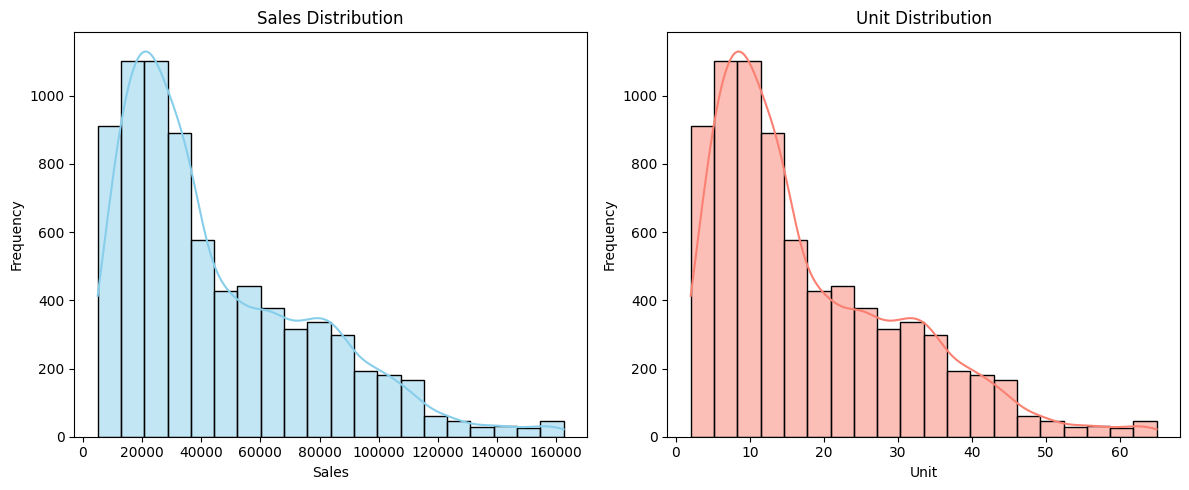

In [32]:
# Create the 'canvas' with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First Chart: Sales (Notice: sns.histplot goes FIRST, then we define the ax)
sns.histplot(df['Sales'], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Second Chart: Unit
sns.histplot(df['Unit'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Unit Distribution')
axes[1].set_xlabel('Unit')
axes[1].set_ylabel('Frequency')

# Clean up the layout and show
plt.tight_layout()
plt.show()

**Observations (histogram):**
- **Right-Skewed Distribution:** The peak (mode) is around 20,000, but the data stretches all the way to 160,000. This "skew" means that while most sales are small, the higher values are frequent enough to create a long slope.

- **Deviation from Normality:** The line chart shows that the data is not normally distributed.


- **Identical Distribution Patterns:** Both Sales and Unit exhibit a nearly identical Right-Skewed shape. This suggests a very strong linear relationship between the two variables—as the number of units increases, the sales value increases proportionally.

- **Peak Activity (Mode):** Most transactions involve approximately 8–10 units.

Most transaction values hover around $20,000.

**The "Long Tail" Logic:** The outliers we saw in the Sales boxplot (the $160k values) correspond directly to the outliers in the Unit distribution (the 60+ unit values).

Insight: These aren't "expensive single items"; these are bulk purchases.

Non-Normality: Neither variable follows a Gaussian (Normal) distribution. Both have "fat tails," meaning the business frequently sees high-volume orders that fall outside the "standard" day-to-day range.

#### **Boxplot**

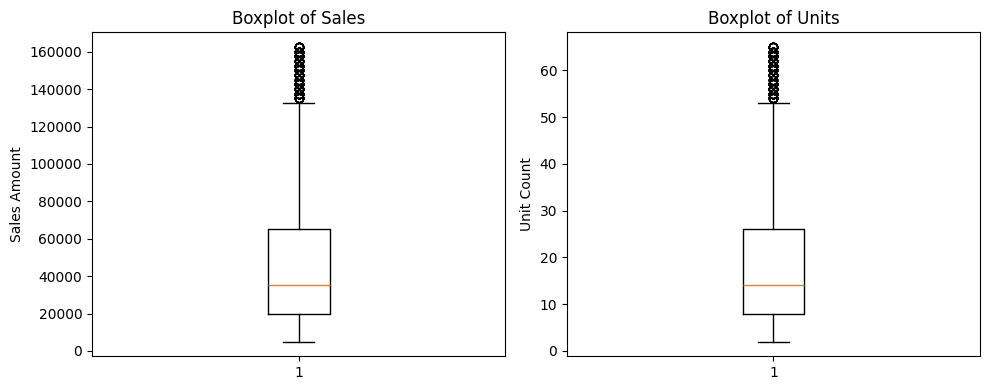

In [15]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot Sales in the first spot
axes[0].boxplot(df['Sales'])
axes[0].set_title('Boxplot of Sales')
axes[0].set_ylabel('Sales Amount')

# Plot Unit in the second spot
axes[1].boxplot(df['Unit'])
axes[1].set_title('Boxplot of Units')
axes[1].set_ylabel('Unit Count')

plt.tight_layout() # Prevents the charts from overlapping
plt.show()

**Observations (boxplot):**

- **Positive (Right) Skewness:** The median line (orange) is positioned closer to the bottom of the box, and the upper "whisker" is significantly longer than the lower one. This indicates that most sales transactions are for smaller amounts, while a few transactions are much higher.

- **Presence of Significant Outliers:** There is a dense cluster of outliers (represented by circles) starting above 130,000 and extending up to 160,000.

- **Central Tendency:** The Median sales value sits at approximately 35,000, which is a more reliable "typical" value for this dataset than the mean due to the skewness.

- **Interquartile Range (IQR):** The middle 50% of sales fall roughly between 20,000 and 65,000. This defines our "normal" range for typical business activity.

#### **Scatter Plot**

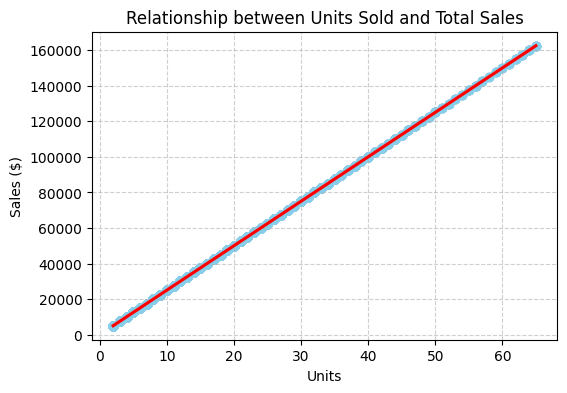

In [16]:
plt.figure(figsize=(6, 4))

# Create the scatter plot
# 'reg' adds a regression line to show the linear trend
sns.regplot(data=df, x='Unit', y='Sales',
            scatter_kws={'alpha':0.5, 'color':'skyblue'},
            line_kws={'color':'red'})

plt.title('Relationship between Units Sold and Total Sales')
plt.xlabel('Units')
plt.ylabel('Sales ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Observations (scatterplot)**
- **Perfect Positive Correlation:** There is a near-perfect linear relationship between Units and Sales. As the number of units increases, the sales value increases at a completely predictable rate.

- **Constant Price Point:** Because the dots fall almost exactly on the red regression line with almost no "noise" or "jitter," it indicates that the Price per Unit is constant across the entire dataset (or the variation in price is extremely negligible).

**Strategic Note:**

**Handling Outliers & Normalization**

**Decision:** The outliers identified in the Boxplot and the right-skewed distribution seen in the Histogram will be retained, and formal normalization (like Scaling or Log Transformation) will not be applied at this stage.

**Reasoning:**

_Preserving Business Reality:_ In sales data, extreme values are often "true" events (e.g., holiday peaks or bulk orders). Removing them would lead to an underestimation of total revenue potential.

In [33]:
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

In [24]:
#df.groupby('Time')['Sales'].sum().sort_values()
# data.groupby('categorical variable')['Numeric variable'].aggregation().sort_values()

df.groupby('Time')[['Unit','Sales']].sum().sort_values(by='Sales', ascending=False).T

Time,Morning,Afternoon,Evening
Unit,45683,45603,44835
Sales,114207500,114007500,112087500


**Time:** There's no notable difference between the sales time. The sales are almost the same in morming, afternoon, and evening

In [25]:
df.groupby('State')[['Unit', 'Sales']].sum().sort_values(by='Sales', ascending=False).T

State,VIC,NSW,SA,QLD,TAS,NT,WA
Unit,42226,29988,23543,13367,9104,9032,8861
Sales,105565000,74970000,58857500,33417500,22760000,22580000,22152500


**Geographic Dominance:** Sales are heavily concentrated in VIC (Victoria), which generates more than 4.5 times the revenue of lowest-performing state (WA).

In [26]:
df.groupby('Group')[['Unit','Sales']].sum().sort_values(by='Sales', ascending=False).T

Group,Men,Women,Kids,Seniors
Unit,34300,34177,34029,33615
Sales,85750000,85442500,85072500,84037500


**Demographic Equality:** Surprisingly, there is no significant difference in sales performance between Men, Women, Kids, and Seniors. Each group contributes roughly 25% of the total volume, showing the products have a universal appeal across all age and gender segments.